[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sandeshjung/Machine-Learning-Foundation/blob/main/02_Supervised_classification/knn.ipynb)

In [1]:
# Colab setup: install the shared helpers (mlf_utils) and any extra packages. Does nothing when run locally.
import sys
if "google.colab" in sys.modules:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/sandeshjung/Machine-Learning-Foundation.git")

# k-Nearest Neighbours (k-NN)

k-NN is the simplest non-parametric classifier: it has **no training phase**. To classify a new point it finds the $k$ closest training points and takes a (possibly distance-weighted) majority vote of their labels. All the "learning" happens at prediction time, which is why it is called a **lazy** learner.

$$\large \hat{y}(\mathbf{x}) = \arg\max_{c} \sum_{i \in \mathcal{N}_k(\mathbf{x})} w_i \, \mathbb{1}[y_i = c], \qquad w_i = 1 \;\text{(uniform)} \;\text{ or }\; w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i)} \;\text{(distance)}$$

Theory: [k-Nearest Neighbours](README.md#4-k-nearest-neighbours)

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from mlf_utils import check_agreement, check_close, plot_decision_regions

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

## Data: two interleaving moons
A non-linear boundary that a linear model can't capture. Features are standardised because k-NN is distance-based (see the scaling pitfall at the end).

In [3]:
X_np, y_np = make_moons(n_samples=400, noise=0.3, random_state=42)
X_np = StandardScaler().fit_transform(X_np)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X_np, y_np, test_size=0.3, random_state=42)

X_train, X_test = torch.from_numpy(X_train_np).float(), torch.from_numpy(X_test_np).float()
y_train, y_test = torch.from_numpy(y_train_np).long(), torch.from_numpy(y_test_np).long()
X_train.shape, X_test.shape

(torch.Size([280, 2]), torch.Size([120, 2]))

## k-NN from scratch
1. **Distances:** `torch.cdist` computes all pairwise Euclidean distances $\lVert \mathbf{x} - \mathbf{x}_i \rVert_2$ between test and training points in one call. The result is an $(n_{test} \times n_{train})$ matrix.
2. **Neighbours:** `topk(..., largest=False)` picks the $k$ smallest distances in each row.
3. **Vote:** add up each neighbour's weight into its class, then take the argmax.

In [4]:
class PyTorchKNN:
    def __init__(self, k=5, weights="uniform"):
        assert weights in ("uniform", "distance")
        self.k, self.weights = k, weights

    def fit(self, X, y):
        # "Training" is just memorising the data
        self.X_train_, self.y_train_ = X, y
        self.n_classes_ = int(y.max()) + 1
        return self

    def kneighbors(self, X):
        distances = torch.cdist(X, self.X_train_)                            # (n_test, n_train)
        dist_k, idx_k = distances.topk(self.k, dim=1, largest=False)          # k closest per row
        return dist_k, idx_k

    def predict_proba(self, X):
        dist_k, idx_k = self.kneighbors(X)
        labels_k = self.y_train_[idx_k]                                       # (n_test, k)
        if self.weights == "uniform":
            w = torch.ones_like(dist_k)
        else:
            w = 1.0 / dist_k.clamp_min(1e-12)                                  # closer neighbours count more
        votes = torch.zeros(X.shape[0], self.n_classes_)
        votes.scatter_add_(1, labels_k, w)                                    # sum weights per class
        return votes / votes.sum(dim=1, keepdim=True)

    def predict(self, X):
        return self.predict_proba(X).argmax(dim=1)

In [5]:
knn = PyTorchKNN(k=15).fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f"Test accuracy (k=15): {(y_pred == y_test).float().mean():.3f}")

Test accuracy (k=15): 0.900


## Verifying against scikit-learn
Same $k$, same (Euclidean) metric, same weighting: the neighbour indices, probabilities and predictions should be identical. Distances agree to about $10^{-5}$: for speed, `torch.cdist` computes $\lVert a - b \rVert^2 = \lVert a \rVert^2 + \lVert b \rVert^2 - 2a^\top b$ with a matrix multiply, which loses a little float32 precision (pass `compute_mode="donot_use_mm_for_euclid_dist"` for the exact but slower version).

In [6]:
for weights in ["uniform", "distance"]:
    ours = PyTorchKNN(k=15, weights=weights).fit(X_train, y_train)
    sk = KNeighborsClassifier(n_neighbors=15, weights=weights).fit(X_train_np, y_train_np)

    sk_dist, sk_idx = sk.kneighbors(X_test_np)
    our_dist, our_idx = ours.kneighbors(X_test)
    check_close(f"[{weights}] neighbour distances", our_dist, sk_dist, atol=1e-4)
    check_agreement(f"[{weights}] neighbour indices", our_idx, sk_idx, min_agreement=1.0)
    check_close(f"[{weights}] class probabilities", ours.predict_proba(X_test), sk.predict_proba(X_test_np), atol=1e-4)
    check_agreement(f"[{weights}] predictions", ours.predict(X_test), sk.predict(X_test_np), min_agreement=1.0)

✓ [uniform] neighbour distances: matches (max |diff| = 1.04e-05)
✓ [uniform] neighbour indices: 100.0% agreement
✓ [uniform] class probabilities: matches (max |diff| = 2.78e-08)
✓ [uniform] predictions: 100.0% agreement
✓ [distance] neighbour distances: matches (max |diff| = 1.04e-05)
✓ [distance] neighbour indices: 100.0% agreement
✓ [distance] class probabilities: matches (max |diff| = 3.25e-05)
✓ [distance] predictions: 100.0% agreement


## Choosing $k$: the bias-variance trade-off
- **Small $k$** (e.g. 1): the boundary follows every training point, including noise, so training accuracy is perfect but the model overfits (high variance).
- **Large $k$**: the vote averages over a big neighbourhood, so the boundary becomes smooth and eventually too simple (high bias). With $k = n$ it always predicts the majority class.

Odd $k$ avoids ties in binary problems.

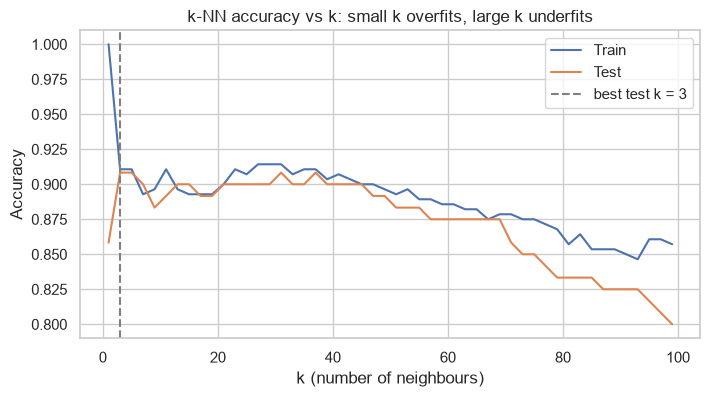

In [7]:
ks = list(range(1, 101, 2))
train_acc, test_acc = [], []
for k in ks:
    model = PyTorchKNN(k=k).fit(X_train, y_train)
    train_acc.append((model.predict(X_train) == y_train).float().mean().item())
    test_acc.append((model.predict(X_test) == y_test).float().mean().item())

best_k = ks[int(np.argmax(test_acc))]
plt.figure(figsize=(8, 4))
plt.plot(ks, train_acc, label="Train")
plt.plot(ks, test_acc, label="Test")
plt.axvline(best_k, color="gray", ls="--", label=f"best test k = {best_k}")
plt.xlabel("k (number of neighbours)"); plt.ylabel("Accuracy"); plt.legend()
plt.title("k-NN accuracy vs k: small k overfits, large k underfits")
plt.show()

*In practice choose $k$ with cross-validation on the training set, not by looking at test accuracy as this illustration does.*

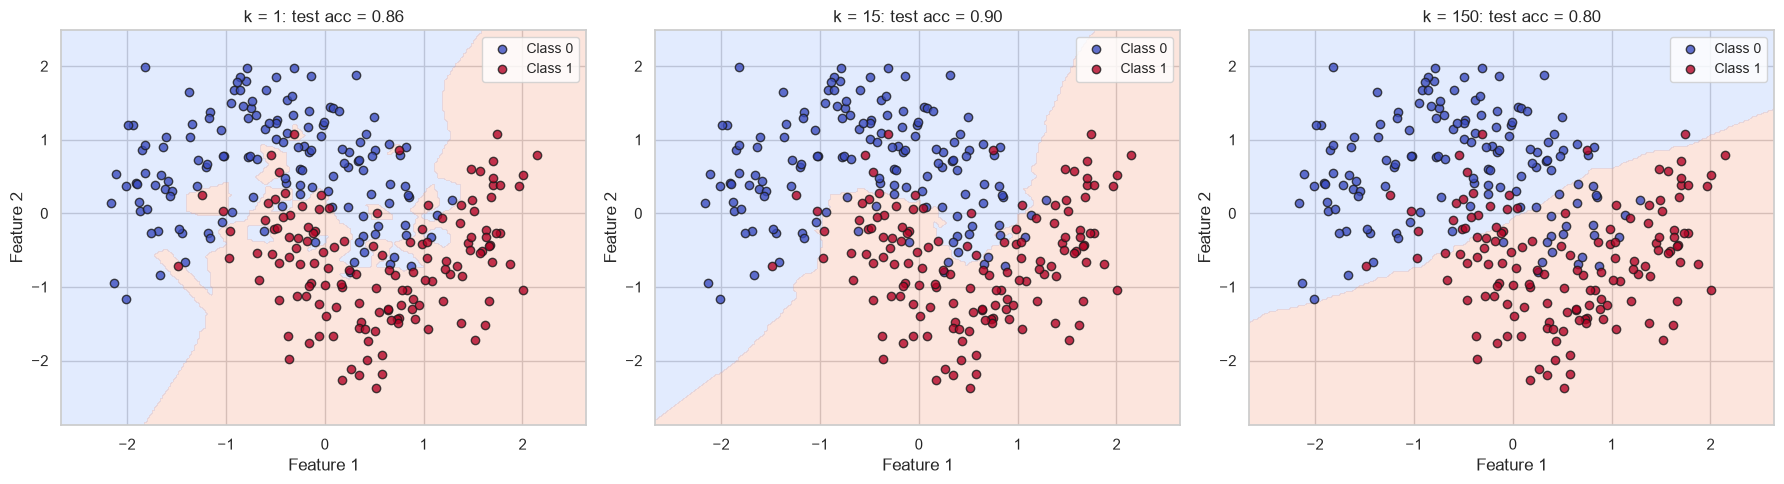

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [1, 15, 150]):
    model = PyTorchKNN(k=k).fit(X_train, y_train)
    plot_decision_regions(lambda g: model.predict(torch.from_numpy(g).float()), X_train_np, y_train_np, ax=ax,
                          title=f"k = {k}: test acc = {(model.predict(X_test) == y_test).float().mean():.2f}")
plt.tight_layout()
plt.show()

## Try it: $k$ and the weighting scheme
Watch the boundary go from jagged ($k=1$) to smooth. With `distance` weighting, close neighbours dominate the vote, so even a large $k$ keeps some local detail. With $k=1$ the training accuracy is always 100%.

*Interactive: run the notebook locally or in Colab to use the controls. GitHub only renders a static page.*

In [9]:
from ipywidgets import Dropdown, IntSlider, interact

@interact(k=IntSlider(value=15, min=1, max=151, step=2, continuous_update=False),
          weights=Dropdown(options=["uniform", "distance"], value="uniform"))
def explore_knn(k, weights):
    model = PyTorchKNN(k=k, weights=weights).fit(X_train, y_train)
    train_acc = (model.predict(X_train) == y_train).float().mean()
    test_acc = (model.predict(X_test) == y_test).float().mean()
    plot_decision_regions(lambda g: model.predict(torch.from_numpy(g).float()), X_train_np, y_train_np,
                          title=f"k = {k}, {weights}: train acc = {train_acc:.2f}, test acc = {test_acc:.2f}")
    plt.show()

interactive(children=(IntSlider(value=15, continuous_update=False, description='k', max=151, min=1, step=2), D…

## Pitfall 1: feature scaling
Distances are dominated by the feature with the largest scale. Below, one feature is multiplied by 1000 (think "income in dollars" next to "age in decades"). Without rescaling, k-NN effectively ignores the other feature.

In [10]:
X_train_bad, X_test_bad = X_train_np.copy(), X_test_np.copy()
X_train_bad[:, 1] *= 1000; X_test_bad[:, 1] *= 1000

acc = lambda Xtr, Xte: (PyTorchKNN(k=15).fit(torch.from_numpy(Xtr).float(), y_train)
                        .predict(torch.from_numpy(Xte).float()) == y_test).float().mean().item()
scaler = StandardScaler().fit(X_train_bad)       # fit on train only
print(f"Original features:            {acc(X_train_np, X_test_np):.3f}")
print(f"Feature 2 multiplied by 1000: {acc(X_train_bad, X_test_bad):.3f}")
print(f"... after StandardScaler:     {acc(scaler.transform(X_train_bad), scaler.transform(X_test_bad)):.3f}")

Original features:            0.900
Feature 2 multiplied by 1000: 0.792
... after StandardScaler:     0.892


## Pitfall 2: the curse of dimensionality
In high dimensions, "nearest" stops meaning much: for random points, the distance to the **nearest** neighbour approaches the distance to the **farthest** one, so every point is roughly equally far away. The plot shows the ratio $d_{min} / d_{max}$ for 1,000 uniformly random points as the dimension grows.

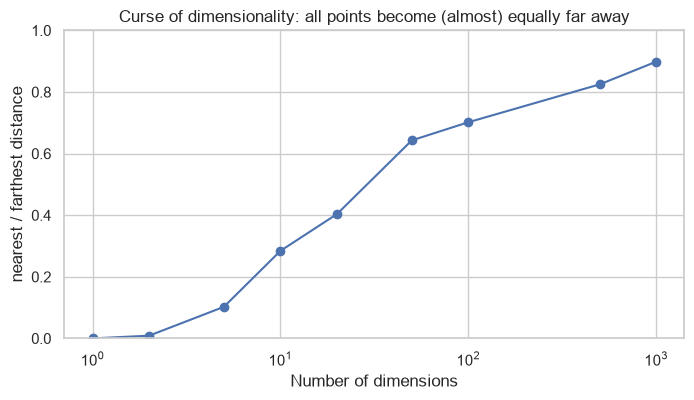

In [11]:
dims = [1, 2, 5, 10, 20, 50, 100, 500, 1000]
ratios = []
gen = torch.Generator().manual_seed(0)
for d in dims:
    points = torch.rand(1000, d, generator=gen)
    query = torch.rand(1, d, generator=gen)
    dist = torch.cdist(query, points).squeeze()
    ratios.append((dist.min() / dist.max()).item())

plt.figure(figsize=(8, 4))
plt.semilogx(dims, ratios, "o-")
plt.xlabel("Number of dimensions"); plt.ylabel("nearest / farthest distance")
plt.title("Curse of dimensionality: all points become (almost) equally far away")
plt.ylim(0, 1)
plt.show()

## Summary
| | k-NN |
|---|---|
| Training cost | $O(1)$ (just stores the data) |
| Prediction cost | $O(n \cdot d)$ per query (brute force). KD-trees and ball trees help in low dimensions |
| Hyperparameters | $k$, distance metric, weighting |
| Strengths | No training, naturally multi-class, flexible non-linear boundaries, easy to explain ("these 5 similar cases were…") |
| Weaknesses | Slow and memory-hungry at prediction time, needs scaling, degrades in high dimensions, sensitive to irrelevant features |